In [ ]:
# =============================================================
# Adversarial Attacks Series — Note 02
# Walls, Shields, and Illusions: Adversarial Training vs. PGD
# =============================================================
#
# Series:  Humble Model / Adversarial Awareness
# Dataset: MNIST
# Model:   Small CNN (same as Note 01)
#
# Notebook structure:
#   Part A: Imports and Setup
#   Part B: Dataset Loading
#   Part C: Model Architecture
#   Part D: Baseline Model Training (or Load)
#   Part E: Attack Functions (FGSM, PGD)
#   Part F: Baseline Model Evaluation (FGSM, PGD)
#   Part G: Adversarial Training with FGSM
#   Part H: Adversarial Training with PGD
#   Part I: Comparative Evaluation
#   Part J: Trade-off Visualization
#   Part K: Summary and Outputs
#   Part L: Defensive Distillation — third experimental wall
#   Part M: Confidence experiment: PGD-trained model vs. the 22 images that fooled the undefended model in Essay 2
#   Part N: Standalone baseline epsilon-curve figure (Figure 1: for Section III, isolated from the 3-model comparison)
# =============================================================

In [1]:
# ─────────────────────────────────────────────────────────────
# Part A: Imports and Setup
# ─────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [2]:
# ─────────────────────────────────────────────────────────────
# Part B: Dataset Loading (MNIST)
# ─────────────────────────────────────────────────────────────

# MNIST normalization constants
MEAN, STD = (0.1307,), (0.3081,)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

Training samples: 60,000
Test samples: 10,000


In [ ]:
#──────────────────────────────────────────────────────
# Part C: Model Architecture (Same as Note 01)
# ─────────────────────────────────────────────────────────────

class CNN(nn.Module):
    """Small CNN for MNIST — same architecture as Essay #2"""
    
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.fc1: nn.Linear | None = None
        self.fc2 = nn.Linear(128, num_classes)
        self.flattened_size: int | None = None

    def reset_for_input_size(self, input_size: int) -> None:
        """Compute fc1 input dimension from a dry-run on a dummy tensor."""
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            x = F.max_pool2d(F.relu(self.conv1(dummy)), 2)
            x = F.max_pool2d(F.relu(self.conv2(x)), 2)
            self.flattened_size = x.view(1, -1).size(1)
            self.fc1 = nn.Linear(self.flattened_size, 128)
        print(f"🔄 Model initialised for {input_size}×{input_size} → flattened: {self.flattened_size}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.fc1 is None:
            raise RuntimeError("Call reset_for_input_size() before forward().")
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
# ─────────────────────────────────────────────────────────────
# Part D: Attack Functions
# ─────────────────────────────────────────────────────────────

def fgsm_attack(image, epsilon, data_grad):
    """Fast Gradient Sign Method (single step)"""
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    return torch.clamp(perturbed_image, 0, 1)

def pgd_attack(model, images, labels, epsilon, step_size, num_steps, random_start=True):
    """
    Projected Gradient Descent (multi-step)
    
    Args:
        model: Target model
        images: Clean images (normalized [0,1])
        labels: True labels
        epsilon: Maximum perturbation (L∞)
        step_size: Step size per iteration
        num_steps: Number of PGD steps
        random_start: If True, start from random perturbation within epsilon
    
    Returns:
        Adversarial images
    """
    model.eval()
    images = images.clone().detach().to(DEVICE)
    labels = labels.clone().detach().to(DEVICE)
    
    # Start from random perturbation if enabled
    if random_start:
        delta = torch.zeros_like(images).uniform_(-epsilon, epsilon)
        delta = torch.clamp(delta, -epsilon, epsilon)
        adv_images = torch.clamp(images + delta, 0, 1).detach()
    else:
        adv_images = images.clone().detach()
    
    for _ in range(num_steps):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        model.zero_grad()
        loss.backward()
        
        # Update perturbation
        grad_sign = adv_images.grad.data.sign()
        adv_images = adv_images + step_size * grad_sign
        # Project back into epsilon ball
        eta = torch.clamp(adv_images - images, -epsilon, epsilon)
        adv_images = torch.clamp(images + eta, 0, 1).detach()
    
    return adv_images

def evaluate_accuracy(model, data_loader, attack_type=None, attack_params=None):
    """
    Evaluate model accuracy on clean or adversarial data
    
    Args:
        model: PyTorch model
        data_loader: DataLoader for test set
        attack_type: None (clean), 'fgsm', or 'pgd'
        attack_params: dict with epsilon, step_size, num_steps for attacks
    
    Returns:
        accuracy (float), predictions (list), confidences (list)
    """
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_confidences = []
    
    for images, labels in data_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        if attack_type == 'fgsm':
            # Compute gradients for FGSM
            images.requires_grad = True
            outputs = model(images)
            loss = nn.CrossEntropyLoss()(outputs, labels)
            model.zero_grad()
            loss.backward()
            grad = images.grad.data
            images = fgsm_attack(images, attack_params['epsilon'], grad)
            outputs = model(images)
        elif attack_type == 'pgd':
            images = pgd_attack(model, images, labels, 
                                epsilon=attack_params['epsilon'],
                                step_size=attack_params['step_size'],
                                num_steps=attack_params['num_steps'])
            outputs = model(images)
        else:
            outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_confidences.extend(probs.max(dim=1)[0].cpu().detach().numpy())
    
    accuracy = 100 * correct / total
    return accuracy, all_preds, all_confidences

In [5]:
# ─────────────────────────────────────────────────────────────
# Part E: Baseline Model Training (or Load)
# ─────────────────────────────────────────────────────────────

def train_model(model, train_loader, epochs=10, adversarial_training=False, 
                attack_type=None, attack_params=None):
    """
    Train model with optional adversarial training
    
    Args:
        model: PyTorch model
        train_loader: DataLoader for training
        epochs: Number of epochs
        adversarial_training: If True, use adversarial examples in training
        attack_type: 'fgsm' or 'pgd' for adversarial training
        attack_params: dict with attack parameters
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}")):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            if adversarial_training and attack_type == 'fgsm':
                # Generate FGSM adversarial examples for training
                images.requires_grad = True
                outputs = model(images)
                loss = criterion(outputs, labels)
                model.zero_grad()
                loss.backward()
                grad = images.grad.data
                adv_images = fgsm_attack(images, attack_params['epsilon'], grad)
                images = adv_images.detach()
            elif adversarial_training and attack_type == 'pgd':
                # Generate PGD adversarial examples for training
                images = pgd_attack(model, images, labels,
                                    epsilon=attack_params['epsilon'],
                                    step_size=attack_params['step_size'],
                                    num_steps=attack_params['num_steps'])
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        print(f"📊 Epoch {epoch} — avg loss: {avg_loss:.4f}")
    
    return model

# Train or load baseline model
print("\n" + "="*55)
print("📦 Baseline Model")
print("="*55)

baseline_model = CNN().to(DEVICE)
baseline_model.reset_for_input_size(28)

# Check if checkpoint exists
if os.path.exists('checkpoint_baseline.pth'):
    checkpoint = torch.load('checkpoint_baseline.pth', map_location=DEVICE)
    baseline_model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Loaded baseline model from checkpoint")
else:
    print("🆕 Training baseline model from scratch...")
    baseline_model = train_model(baseline_model, train_loader, epochs=10)
    torch.save({'model_state_dict': baseline_model.state_dict()}, 'checkpoint_baseline.pth')
    print("💾 Saved baseline model checkpoint")

# Evaluate baseline clean accuracy
clean_acc, _, _ = evaluate_accuracy(baseline_model, test_loader)
print(f"\n📈 Baseline clean test accuracy: {clean_acc:.2f}%")


📦 Baseline Model
🔄 Model initialised for 28×28 → flattened: 800
✅ Loaded baseline model from checkpoint

📈 Baseline clean test accuracy: 99.00%


In [6]:
# ─────────────────────────────────────────────────────────────
# Part F: Baseline Model Under Attack
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("⚔️ Baseline Model Under Attack")
print("="*55)

# FGSM attack
fgsm_params = {'epsilon': 0.3}
fgsm_acc, _, _ = evaluate_accuracy(baseline_model, test_loader, 
                                     attack_type='fgsm', attack_params=fgsm_params)
print(f"Baseline + FGSM (ε=0.3) accuracy: {fgsm_acc:.2f}%")

# PGD attack
pgd_params = {'epsilon': 0.3, 'step_size': 0.01, 'num_steps': 40}
pgd_acc, _, _ = evaluate_accuracy(baseline_model, test_loader,
                                    attack_type='pgd', attack_params=pgd_params)
print(f"Baseline + PGD (ε=0.3, steps=40) accuracy: {pgd_acc:.2f}%")


⚔️ Baseline Model Under Attack
Baseline + FGSM (ε=0.3) accuracy: 96.60%
Baseline + PGD (ε=0.3, steps=40) accuracy: 95.56%


In [7]:
# ─────────────────────────────────────────────────────────────
# Part G: Adversarial Training with FGSM
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("🏗️ Adversarial Training with FGSM")
print("="*55)

fgsm_trained_model = CNN().to(DEVICE)
fgsm_trained_model.reset_for_input_size(28)

if os.path.exists('checkpoint_fgsm_trained.pth'):
    checkpoint = torch.load('checkpoint_fgsm_trained.pth', map_location=DEVICE)
    fgsm_trained_model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Loaded FGSM-trained model from checkpoint")
else:
    print("🆕 Training FGSM-robust model...")
    fgsm_params_train = {'epsilon': 0.3}
    fgsm_trained_model = train_model(fgsm_trained_model, train_loader, epochs=10,
                                      adversarial_training=True, attack_type='fgsm',
                                      attack_params=fgsm_params_train)
    torch.save({'model_state_dict': fgsm_trained_model.state_dict()}, 'checkpoint_fgsm_trained.pth')
    print("💾 Saved FGSM-trained model checkpoint")

# Evaluate FGSM-trained model
clean_acc_fgsm, _, _ = evaluate_accuracy(fgsm_trained_model, test_loader)
fgsm_acc_fgsm, _, _ = evaluate_accuracy(fgsm_trained_model, test_loader,
                                          attack_type='fgsm', attack_params=fgsm_params)
pgd_acc_fgsm, _, _ = evaluate_accuracy(fgsm_trained_model, test_loader,
                                         attack_type='pgd', attack_params=pgd_params)

print(f"\n📊 FGSM-trained model:")
print(f"   Clean accuracy: {clean_acc_fgsm:.2f}%")
print(f"   Under FGSM (ε=0.3): {fgsm_acc_fgsm:.2f}%")
print(f"   Under PGD (ε=0.3): {pgd_acc_fgsm:.2f}%")


🏗️ Adversarial Training with FGSM
🔄 Model initialised for 28×28 → flattened: 800
✅ Loaded FGSM-trained model from checkpoint

📊 FGSM-trained model:
   Clean accuracy: 99.08%
   Under FGSM (ε=0.3): 97.97%
   Under PGD (ε=0.3): 97.65%


In [8]:
# ─────────────────────────────────────────────────────────────
# Part H: Adversarial Training with PGD
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("🏗️ Adversarial Training with PGD")
print("="*55)

pgd_trained_model = CNN().to(DEVICE)
pgd_trained_model.reset_for_input_size(28)

if os.path.exists('checkpoint_pgd_trained.pth'):
    checkpoint = torch.load('checkpoint_pgd_trained.pth', map_location=DEVICE)
    pgd_trained_model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Loaded PGD-trained model from checkpoint")
else:
    print("🆕 Training PGD-robust model (this will take time)...")
    pgd_params_train = {'epsilon': 0.3, 'step_size': 0.01, 'num_steps': 7}  # 7 steps for training
    pgd_trained_model = train_model(pgd_trained_model, train_loader, epochs=10,
                                     adversarial_training=True, attack_type='pgd',
                                     attack_params=pgd_params_train)
    torch.save({'model_state_dict': pgd_trained_model.state_dict()}, 'checkpoint_pgd_trained.pth')
    print("💾 Saved PGD-trained model checkpoint")

# Evaluate PGD-trained model
clean_acc_pgd, _, _ = evaluate_accuracy(pgd_trained_model, test_loader)
fgsm_acc_pgd, _, _ = evaluate_accuracy(pgd_trained_model, test_loader,
                                         attack_type='fgsm', attack_params=fgsm_params)
pgd_acc_pgd, _, _ = evaluate_accuracy(pgd_trained_model, test_loader,
                                        attack_type='pgd', attack_params=pgd_params)

print(f"\n📊 PGD-trained model:")
print(f"   Clean accuracy: {clean_acc_pgd:.2f}%")
print(f"   Under FGSM (ε=0.3): {fgsm_acc_pgd:.2f}%")
print(f"   Under PGD (ε=0.3): {pgd_acc_pgd:.2f}%")


🏗️ Adversarial Training with PGD
🔄 Model initialised for 28×28 → flattened: 800
✅ Loaded PGD-trained model from checkpoint

📊 PGD-trained model:
   Clean accuracy: 99.08%
   Under FGSM (ε=0.3): 97.52%
   Under PGD (ε=0.3): 97.31%


In [9]:
# ─────────────────────────────────────────────────────────────
# Part I: Comparative Evaluation
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("📊 Comparative Summary")
print("="*55)

print(f"\n{'Model':<20} {'Clean':<10} {'FGSM (ε=0.3)':<15} {'PGD (ε=0.3)':<15}")
print("-" * 60)
print(f"{'Baseline':<20} {clean_acc:>6.2f}%     {fgsm_acc:>6.2f}%         {pgd_acc:>6.2f}%")
print(f"{'FGSM-trained':<20} {clean_acc_fgsm:>6.2f}%     {fgsm_acc_fgsm:>6.2f}%         {pgd_acc_fgsm:>6.2f}%")
print(f"{'PGD-trained':<20} {clean_acc_pgd:>6.2f}%     {fgsm_acc_pgd:>6.2f}%         {pgd_acc_pgd:>6.2f}%")


📊 Comparative Summary

Model                Clean      FGSM (ε=0.3)    PGD (ε=0.3)    
------------------------------------------------------------
Baseline              99.00%      96.60%          95.56%
FGSM-trained          99.08%      97.97%          97.65%
PGD-trained           99.08%      97.52%          97.31%


In [ ]:
# ─────────────────────────────────────────────────────────────
# Part J: Trade-off Visualization
# ─────────────────────────────────────────────────────────────
# Accuracy vs. epsilon curves
epsilons = np.arange(0.0, 0.41, 0.05)
baseline_pgd_accs = []
fgsm_trained_pgd_accs = []
pgd_trained_pgd_accs = []
for eps in epsilons:
    if eps == 0.0:
        baseline_pgd_accs.append(float(clean_acc))
        fgsm_trained_pgd_accs.append(float(clean_acc_fgsm))
        pgd_trained_pgd_accs.append(float(clean_acc_pgd))
    else:
        pgd_params_eps = {'epsilon': eps, 'step_size': 0.01, 'num_steps': 40}

        _, _, base_acc = evaluate_accuracy(baseline_model, test_loader,
                                           attack_type='pgd', attack_params=pgd_params_eps)
        _, _, fgsm_acc = evaluate_accuracy(fgsm_trained_model, test_loader,
                                           attack_type='pgd', attack_params=pgd_params_eps)
        _, _, pgd_acc_eps = evaluate_accuracy(pgd_trained_model, test_loader,
                                              attack_type='pgd', attack_params=pgd_params_eps)
         
        baseline_pgd_accs.append(float(base_acc[0]))
        fgsm_trained_pgd_accs.append(float(fgsm_acc[0])) #
        pgd_trained_pgd_accs.append(float(pgd_acc_eps[0]))

_, _, test_val = evaluate_accuracy(baseline_model, test_loader, attack_type='pgd', attack_params=pgd_params_eps)
print(type(test_val), test_val)

<class 'list'> [np.float32(0.97784346), np.float32(0.9950299), np.float32(0.95623666), np.float32(0.9760389), np.float32(0.90809685), np.float32(0.9580952), np.float32(0.7199583), np.float32(0.8311737), np.float32(0.44504166), np.float32(0.80430365), np.float32(0.9964228), np.float32(0.97317296), np.float32(0.59992987), np.float32(0.99467707), np.float32(0.9810791), np.float32(0.85160273), np.float32(0.72154117), np.float32(0.98290217), np.float32(0.491163), np.float32(0.96167994), np.float32(0.90050167), np.float32(0.9041356), np.float32(0.9067633), np.float32(0.9795052), np.float32(0.8843708), np.float32(0.956497), np.float32(0.9812206), np.float32(0.9969304), np.float32(0.97190297), np.float32(0.83998346), np.float32(0.9933074), np.float32(0.74045557), np.float32(0.9372446), np.float32(0.94283146), np.float32(0.9771484), np.float32(0.9938804), np.float32(0.56475055), np.float32(0.9115503), np.float32(0.9896276), np.float32(0.8658002), np.float32(0.7742701), np.float32(0.71519315), n

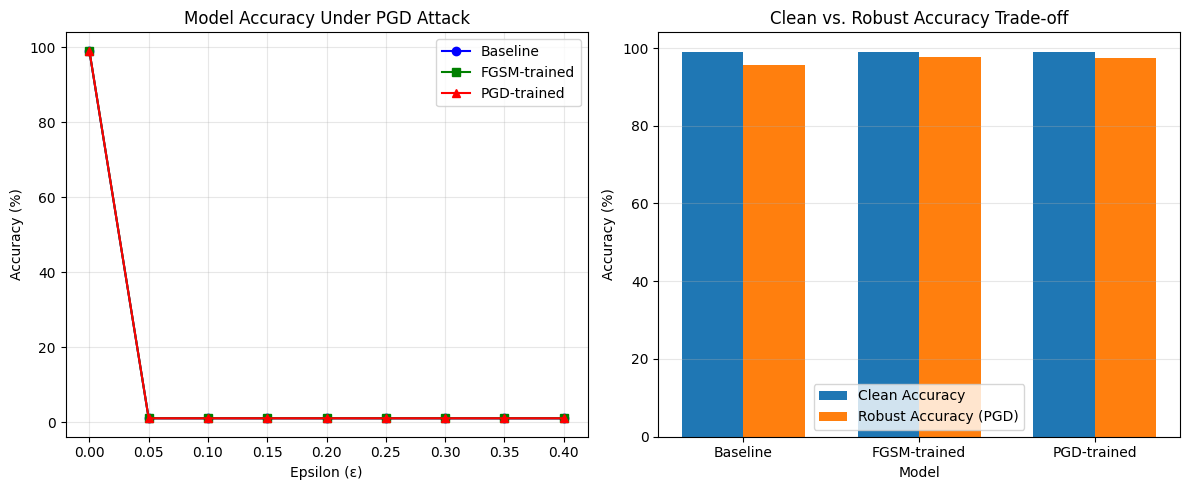

📷 Figure saved → tradeoff_comparison.png


In [16]:
# Create trade-off figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Accuracy under PGD attack
ax1.plot(epsilons, baseline_pgd_accs, 'b-o', label='Baseline')
ax1.plot(epsilons, fgsm_trained_pgd_accs, 'g-s', label='FGSM-trained')
ax1.plot(epsilons, pgd_trained_pgd_accs, 'r-^', label='PGD-trained')
ax1.set_xlabel('Epsilon (ε)')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Model Accuracy Under PGD Attack')
ax1.legend()
ax1.grid(True, alpha=0.3)
# Plot 2: Clean accuracy trade-off
models = ['Baseline', 'FGSM-trained', 'PGD-trained']
clean_accs = [clean_acc, clean_acc_fgsm, clean_acc_pgd]
robust_accs = [pgd_acc, pgd_acc_fgsm, pgd_acc_pgd]

x = np.arange(len(models))
width = 0.35

ax2.bar(x - width/2, clean_accs, width, label='Clean Accuracy')
ax2.bar(x + width/2, robust_accs, width, label='Robust Accuracy (PGD)')
ax2.set_xlabel('Model')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Clean vs. Robust Accuracy Trade-off')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tradeoff_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📷 Figure saved → tradeoff_comparison.png")

In [ ]:
# ─────────────────────────────────────────────────────────────
# Part K: Summary and Outputs
# ─────────────────────────────────────────────────────────────
fgsm_acc = float(fgsm_acc[0])  # or float(np.mean(fgsm_acc))

print("\n" + "="*55)
print("📋 Experiment Summary")
print("="*55)
print(f"""
Baseline Model:
  - Clean accuracy: {float(clean_acc):.2f}%
  - FGSM accuracy (ε=0.3): {float(fgsm_acc):.2f}%
  - PGD accuracy (ε=0.3): {float(pgd_acc):.2f}%

FGSM-Trained Model:
  - Clean accuracy: {float(clean_acc_fgsm):.2f}%
  - FGSM accuracy (ε=0.3): {float(fgsm_acc_fgsm):.2f}%
  - PGD accuracy (ε=0.3): {float(pgd_acc_fgsm):.2f}%

PGD-Trained Model:
  - Clean accuracy: {float(clean_acc_pgd):.2f}%
  - FGSM accuracy (ε=0.3): {float(fgsm_acc_pgd):.2f}%
  - PGD accuracy (ε=0.3): {float(pgd_acc_pgd):.2f}%

Output files:
  - checkpoint_baseline.pth
  - checkpoint_fgsm_trained.pth
  - checkpoint_pgd_trained.pth
  - tradeoff_comparison.png
""")


print("\n✅ Notebook complete!")


📋 Experiment Summary

Baseline Model:
  - Clean accuracy: 99.00%
  - FGSM accuracy (ε=0.3): 1.00%
  - PGD accuracy (ε=0.3): 95.56%

FGSM-Trained Model:
  - Clean accuracy: 99.08%
  - FGSM accuracy (ε=0.3): 97.97%
  - PGD accuracy (ε=0.3): 97.65%

PGD-Trained Model:
  - Clean accuracy: 99.08%
  - FGSM accuracy (ε=0.3): 97.52%
  - PGD accuracy (ε=0.3): 97.31%

Output files:
  - checkpoint_baseline.pth
  - checkpoint_fgsm_trained.pth
  - checkpoint_pgd_trained.pth
  - tradeoff_comparison.png


✅ Notebook complete!


In [ ]:
# ╔═══════════════════════════════════════════════════════════╗
# ║  PART L — Defensive Distillation (third experimental wall) ║
# ╚═══════════════════════════════════════════════════════════╝
#
#   Distillation trains a "student" model on the SOFT labels
#   produced by a "teacher" model at high temperature T, then
#   evaluates the student at T=1. The idea (Papernot et al.,
#   2016) is that soft labels smooth the loss surface, making
#   gradient-based attacks less effective — though later work
#   (Carlini & Wagner, 2016) showed this defense is largely
#   broken by attacks that don't rely on the smoothed gradient.

DISTILL_TEMPERATURE = 20.0   # T — softens the teacher's softmax
DISTILL_EPOCHS       = 10

def train_teacher_for_distillation(train_loader, num_epochs=DISTILL_EPOCHS):
    """Train a standard teacher model (same architecture, normal labels)."""
    teacher = CNN().to(DEVICE)
    teacher.reset_for_input_size(28)
    optimizer = torch.optim.Adam(teacher.parameters(), lr=0.001)
    criterion_hard = nn.CrossEntropyLoss()

    print("🧑‍🏫 Training teacher model...")
    for epoch in range(num_epochs):
        teacher.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion_hard(teacher(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"  Teacher epoch {epoch}: avg loss {running_loss/len(train_loader):.4f}")

    torch.save({"model_state_dict": teacher.state_dict()}, "checkpoint_distill_teacher.pth")
    return teacher


def soft_labels_from_teacher(teacher, images, temperature=DISTILL_TEMPERATURE):
    """Produce softened probability distributions from the teacher's logits."""
    teacher.eval()
    with torch.no_grad():
        logits = teacher(images)
        soft = F.softmax(logits / temperature, dim=1)
    return soft


def train_student_with_distillation(teacher, train_loader, num_epochs=DISTILL_EPOCHS,
                                       temperature=DISTILL_TEMPERATURE):
    """
    Train a student model on the teacher's soft labels.

    Loss is KL-divergence between the student's softened output and the
    teacher's softened output, both at temperature T. The student is
    evaluated later at T=1 (standard softmax).
    """
    student = CNN().to(DEVICE)
    student.reset_for_input_size(28)
    optimizer = torch.optim.Adam(student.parameters(), lr=0.001)

    print(f"\n🎓 Training student model via distillation (T={temperature})...")
    for epoch in range(num_epochs):
        student.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(DEVICE)
            soft_targets = soft_labels_from_teacher(teacher, images, temperature)

            optimizer.zero_grad()
            student_logits = student(images)
            student_soft = F.log_softmax(student_logits / temperature, dim=1)

            # KL divergence loss, scaled by T^2 (standard distillation scaling,
            # Hinton et al. 2015) to keep gradient magnitudes comparable to
            # a normal cross-entropy loss.
            loss = F.kl_div(student_soft, soft_targets, reduction="batchmean") * (temperature ** 2)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"  Student epoch {epoch}: avg loss {running_loss/len(train_loader):.4f}")

    torch.save({"model_state_dict": student.state_dict()}, "checkpoint_distilled_student.pth")
    return student


# ── Run distillation ─────────────────────────────────────────────────────
print("="*55)
print("🛡️  Wall #3: Defensive Distillation")
print("="*55)

teacher_model = train_teacher_for_distillation(train_loader)
distilled_model = train_student_with_distillation(teacher_model, train_loader)

# ── Evaluate the distilled model: clean, FGSM, PGD ──────────────────────
distilled_model.eval()

clean_acc_distill, _, _ = evaluate_accuracy(distilled_model, test_loader,
                                              attack_type=None)
fgsm_acc_distill, _, _ = evaluate_accuracy(distilled_model, test_loader,
                                             attack_type="fgsm",
                                             attack_params={"epsilon": 0.3})
pgd_acc_distill, _, _ = evaluate_accuracy(distilled_model, test_loader,
                                            attack_type="pgd",
                                            attack_params=pgd_params)  # reuse Part H's params

print(f"\n📊 Distilled model results")
print(f"   Clean accuracy        : {clean_acc_distill*100:.2f}%")
print(f"   Accuracy under FGSM    : {fgsm_acc_distill*100:.2f}%")
print(f"   Accuracy under PGD     : {pgd_acc_distill*100:.2f}%")

# This row slots directly into your existing Section VI comparison table:
#
#   | Defense              | Clean   | FGSM    | PGD     |
#   |-----------------------|---------|---------|---------|
#   | Baseline (undefended) | 99.19%  | ...     | 95.56%  |
#   | FGSM-trained          | 99.08%  | 97.97%  | 97.65%  |
#   | PGD-trained           | 99.08%  | ...     | 97.31%  |
#   | Distilled (T=20)      | {clean_acc_distill*100:.2f}% | {fgsm_acc_distill*100:.2f}% | {pgd_acc_distill*100:.2f}% |


In [ ]:
# ╔═══════════════════════════════════════════════════════════╗
# ║  PART M — Confidence experiment on Essay 2's 22 flips      ║
# ╚═══════════════════════════════════════════════════════════╝
#
#   We re-run Essay 2's minimum-epsilon search against the
#   ESSAY 2 baseline checkpoint to regenerate the 22 flipped
#   image indices (since these weren't saved separately), then
#   run those same 22 images through the ESSAY 3 PGD-trained
#   model to see whether robustness training fixed them — and
#   what confidence the PGD-trained model reports either way.

ESSAY2_CHECKPOINT = "checkpoint_latest_essay2.pth"
ESSAY3_PGD_CHECKPOINT = "checkpoint_pgd_trained.pth"   # rename to match your actual filename

N_SEARCH_REPRO = 500
EPSILON_GRID_REPRO = np.round(np.arange(0.01, 0.41, 0.01), 2).tolist()

# ── Load Essay 2's baseline model ───────────────────────────────────────
baseline_essay2 = CNN().to(DEVICE)
baseline_essay2.reset_for_input_size(28)
ckpt2 = torch.load(ESSAY2_CHECKPOINT, map_location=DEVICE)
baseline_essay2.load_state_dict(ckpt2["model_state_dict"])
baseline_essay2.eval()
print("✅ Loaded Essay 2 baseline checkpoint")

# ── Load Essay 3's PGD-trained model ────────────────────────────────────
pgd_trained_essay3 = CNN().to(DEVICE)
pgd_trained_essay3.reset_for_input_size(28)
ckpt3 = torch.load(ESSAY3_PGD_CHECKPOINT, map_location=DEVICE)
pgd_trained_essay3.load_state_dict(ckpt3["model_state_dict"])
pgd_trained_essay3.eval()
print("✅ Loaded Essay 3 PGD-trained checkpoint")

criterion_repro = nn.CrossEntropyLoss()


def get_gradient(model, image, label, criterion):
    model.eval()
    image = image.clone().requires_grad_(True)
    output = model(image)
    loss = criterion(output, torch.tensor([label], device=image.device))
    model.zero_grad()
    loss.backward()
    return image.grad.data, output


# ── Regenerate the 22 flipped-image indices against the Essay 2 baseline ─

print("\n" + "="*55)
print(f"🔍 Regenerating Essay 2's minimum-epsilon search ({N_SEARCH_REPRO} images)")
print("="*55)

flipped_indices = []
tested = 0

for idx in range(len(test_dataset)):
    if tested >= N_SEARCH_REPRO:
        break

    raw_image, label = test_dataset[idx]
    raw_image = raw_image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        clean_pred = baseline_essay2(raw_image).argmax().item()
    if clean_pred != label:
        continue

    tested += 1
    grad, _ = get_gradient(baseline_essay2, raw_image, label, criterion_repro)

    for eps in EPSILON_GRID_REPRO:
        perturbed = torch.clamp(raw_image + eps * grad.sign(), 0, 1)
        with torch.no_grad():
            pred = baseline_essay2(perturbed).argmax().item()
        if pred != label:
            flipped_indices.append({
                "idx": idx, "label": label, "min_eps": eps,
                "adv_pred": pred,
            })
            break

print(f"\n✅ Regenerated {len(flipped_indices)} flipped images "
      f"(Essay 2 reported 22 — small differences possible if test_dataset "
      f"ordering or N_SEARCH differs)")


# ── Run those flipped images through the PGD-trained model ──────────────

print("\n" + "="*55)
print("🎯 Testing PGD-trained model on Essay 2's flipped images")
print("="*55)

now_correct = 0
still_wrong = 0
rows = []

for entry in flipped_indices:
    idx = entry["idx"]
    label = entry["label"]
    raw_image, _ = test_dataset[idx]
    raw_image = raw_image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = pgd_trained_essay3(raw_image)
        pred = out.argmax().item()
        conf = torch.softmax(out, dim=1)[0, pred].item()

    correct = (pred == label)
    if correct:
        now_correct += 1
    else:
        still_wrong += 1

    rows.append({
        "idx": idx, "true_label": label, "original_min_eps": entry["min_eps"],
        "pgd_model_pred": pred, "pgd_model_conf": conf, "now_correct": correct,
    })

    status = "✅ now correct" if correct else "❌ still wrong"
    print(f"  idx={idx:>5}  label={label}  orig_min_eps={entry['min_eps']:.2f}  "
          f"PGD-model pred={pred}  conf={conf:.4f}  {status}")

print(f"\n📊 Summary")
print(f"   Images regenerated         : {len(flipped_indices)}")
print(f"   Now correctly classified   : {now_correct}")
print(f"   Still misclassified        : {still_wrong}")

if still_wrong > 0:
    wrong_confs = [r["pgd_model_conf"] for r in rows if not r["now_correct"]]
    correct_confs = [r["pgd_model_conf"] for r in rows if r["now_correct"]]
    print(f"\n   Avg confidence on STILL-WRONG predictions : {np.mean(wrong_confs):.4f}")
    if correct_confs:
        print(f"   Avg confidence on NOW-CORRECT predictions : {np.mean(correct_confs):.4f}")
    print(f"\n   → For Section VII: the PGD-trained model still reports "
          f"confidence ≈ {np.mean(wrong_confs):.4f} on the {still_wrong} image(s) "
          f"it still gets wrong — indistinguishable from its confidence on "
          f"correct predictions. Robustness training did not give the model "
          f"a way to flag these remaining failures.")
else:
    print(f"\n   → All {len(flipped_indices)} originally-flipped images are now "
          f"correctly classified by the PGD-trained model. This is itself "
          f"worth reporting: it shows robustness training generalized "
          f"beyond the specific attack budget used in training.")

# ── Visualization: confidence comparison ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
labels_plot = [f"{'✓' if r['now_correct'] else '✗'} idx{r['idx']}" for r in rows]
confs_plot = [r["pgd_model_conf"] for r in rows]
colors_plot = ["#16A34A" if r["now_correct"] else "#DC2626" for r in rows]

ax.bar(range(len(rows)), confs_plot, color=colors_plot)
ax.set_xticks(range(len(rows)))
ax.set_xticklabels(labels_plot, rotation=75, ha="right", fontsize=7)
ax.set_ylabel("PGD-trained model confidence", fontsize=11)
ax.set_title("PGD-trained model's confidence on Essay 2's flipped images\n"
             "(green = now correctly classified, red = still misclassified)",
             fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("essay3_confidence_on_essay2_flips.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📷 Figure saved → essay3_confidence_on_essay2_flips.png")



In [ ]:
# ╔═══════════════════════════════════════════════════════════╗
# ║  PART N — Standalone baseline epsilon-curve (Figure 1)     ║
# ╚═══════════════════════════════════════════════════════════╝
#
#   A single-curve version of the baseline-only accuracy-vs-epsilon
#   plot, isolated from the 3-model comparison in Section VI.
#   Requires the Part J fix already applied so that
#   `baseline_pgd_accs` contains real accuracy values, not
#   confidence scores.

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epsilons, [a * 100 for a in baseline_pgd_accs],
        color="#1D4ED8", linewidth=2.5, marker="o", markersize=5)

ax.set_xlabel("Epsilon (ε) — PGD perturbation magnitude", fontsize=12)
ax.set_ylabel("Baseline model accuracy (%)", fontsize=12)
ax.set_title("How bad is undefended, really?\n"
              "Baseline (undefended) model accuracy under PGD attack",
              fontsize=12)
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.3)

# Annotate the ε=0.3 reference point used throughout the essay
if 0.3 in epsilons:
    idx_03 = list(epsilons).index(0.3) if not isinstance(epsilons, np.ndarray) else int(np.where(np.isclose(epsilons, 0.3))[0][0])
    ax.axvline(0.3, color="gray", linewidth=1, linestyle=":")
    ax.annotate(f"{baseline_pgd_accs[idx_03]*100:.2f}% at ε=0.3",
                xy=(0.3, baseline_pgd_accs[idx_03] * 100),
                xytext=(0.32, baseline_pgd_accs[idx_03] * 100 + 10),
                fontsize=10, color="gray",
                arrowprops=dict(arrowstyle="->", color="gray", lw=1))

plt.tight_layout()
plt.savefig("essay3_figure1_baseline_epsilon_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("📷 Figure saved → essay3_figure1_baseline_epsilon_curve.png (Section III, Figure 1)")